In [1]:
# ── Notebook 4: ASR Correlation ────────────────────────────────────────────
# Tests whether phonotactic complexity (bits/phoneme) predicts ASR difficulty
# (Word Error Rate). Uses published WER numbers from the Vistaar benchmark
# (Bhogale et al., Interspeech 2023) — the largest systematic Indic ASR
# evaluation to date, covering 12 languages across 6 ASR systems.
# ───────────────────────────────────────────────────────────────────────────

import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# ── Constants ──────────────────────────────────────────────────────────────
LANGUAGES   = ["hin", "tam", "tel", "eng"]
LANG_NAMES  = {"hin": "Hindi", "tam": "Tamil", "tel": "Telugu", "eng": "English"}
LANG_COLORS = {"hin": "#E63946", "tam": "#2A9D8F", "tel": "#F4A261", "eng": "#457B9D"}

# ── Adjust these paths to match your /kaggle/input/ sidebar ───────────────
NB1 = "/kaggle/input/notebooks/tanveerheir/data-pipeline"
NB2 = "/kaggle/input/notebooks/tanveerheir/trigramlm"
NB3 = "/kaggle/input/notebooks/tanveerheir/lstm-model"

# ── Load Notebook 1 ────────────────────────────────────────────────────────
with open(f"{NB1}/forms.json", encoding="utf-8") as f:
    forms = json.load(f)

# ── Load Notebook 2 ────────────────────────────────────────────────────────
with open(f"{NB2}/ngram_results.json") as f:
    ngram_results = json.load(f)

# ── Load Notebook 3 ────────────────────────────────────────────────────────
with open(f"{NB3}/lstm_results.json") as f:
    lstm_results = json.load(f)

# ── Summary ────────────────────────────────────────────────────────────────
print("Loaded bits/phoneme scores:")
print(f"\n{'Language':<10} {'Trigram':>10} {'LSTM':>10}")
print("-" * 32)
for lid in LANGUAGES:
    tri  = np.mean(ngram_results[lid])
    lstm = np.mean(lstm_results[lid])
    print(f"{LANG_NAMES[lid]:<10} {tri:>10.3f} {lstm:>10.3f}")

Loaded bits/phoneme scores:

Language      Trigram       LSTM
--------------------------------
Hindi           4.008      3.722
Tamil           3.226      3.119
Telugu          3.511      3.283
English         3.690      3.486


In [2]:
# ── Published WER Data ─────────────────────────────────────────────────────
# Source: Bhogale et al. (2023) "Vistaar: The Largest Open Collection of
# Diverse Indic Speech", Interspeech 2023.
# Model: IndicWhisper (best open Indic ASR system in the benchmark)
# Metric: Word Error Rate (%) — lower is better for ASR, higher = harder
# Test sets: FLEURS benchmark, one per language
#
# English WER: OpenAI Whisper (large-v2) on LibriSpeech test-clean
# — standard reference, Radford et al. 2022
# ───────────────────────────────────────────────────────────────────────────

wer_data = {
    # lang_id : {
    #   "wer"    : float  (Word Error Rate %)
    #   "system" : str    (ASR system name)
    #   "test"   : str    (test set name)
    #   "source" : str    (paper citation)
    # }
    "hin": {
        "wer"   : 13.4,
        "system": "IndicWhisper",
        "test"  : "FLEURS-Hindi",
        "source": "Bhogale et al., Interspeech 2023"
    },
    "tam": {
        "wer"   : 30.1,
        "system": "IndicWhisper",
        "test"  : "FLEURS-Tamil",
        "source": "Bhogale et al., Interspeech 2023"
    },
    "tel": {
        "wer"   : 24.7,
        "system": "IndicWhisper",
        "test"  : "FLEURS-Telugu",
        "source": "Bhogale et al., Interspeech 2023"
    },
    "eng": {
        "wer"   : 3.0,
        "system": "Whisper large-v2",
        "test"  : "LibriSpeech test-clean",
        "source": "Radford et al., 2022"
    },
}

print("WER Data (published benchmarks):")
print(f"\n{'Language':<10} {'WER (%)':>8}  {'System':<20} {'Test Set'}")
print("-" * 65)
for lid in LANGUAGES:
    d = wer_data[lid]
    print(f"{LANG_NAMES[lid]:<10} {d['wer']:>8.1f}  {d['system']:<20} {d['test']}")

print()
print("Note: Higher WER = harder for ASR = more errors.")
print("Hypothesis: higher bits/phoneme → higher WER.")

WER Data (published benchmarks):

Language    WER (%)  System               Test Set
-----------------------------------------------------------------
Hindi          13.4  IndicWhisper         FLEURS-Hindi
Tamil          30.1  IndicWhisper         FLEURS-Tamil
Telugu         24.7  IndicWhisper         FLEURS-Telugu
English         3.0  Whisper large-v2     LibriSpeech test-clean

Note: Higher WER = harder for ASR = more errors.
Hypothesis: higher bits/phoneme → higher WER.


In [3]:
rows = []
for lid in LANGUAGES:
    tri_scores  = ngram_results[lid]
    lstm_scores = lstm_results[lid]
    word_lengths = [len(e["phonemes"]) for e in forms[lid]]

    rows.append({
        "lang_id"        : lid,
        "Language"       : LANG_NAMES[lid],
        "Family"         : "Indo-Aryan" if lid == "hin" else
                           "Dravidian"  if lid in ("tam", "tel") else
                           "Germanic",
        "Trigram_bpp"    : np.mean(tri_scores),
        "Trigram_std"    : np.std(tri_scores),
        "LSTM_bpp"       : np.mean(lstm_scores),
        "LSTM_std"       : np.std(lstm_scores),
        "WER"            : wer_data[lid]["wer"],
        "Avg_word_len"   : np.mean(word_lengths),
        "Phoneme_inv"    : len(set(p for e in forms[lid] for p in e["phonemes"])),
    })

df = pd.DataFrame(rows).set_index("Language")

print("Master analysis table:")
print(df[["Family","Trigram_bpp","LSTM_bpp","WER",
          "Avg_word_len","Phoneme_inv"]].to_string())

Master analysis table:
              Family  Trigram_bpp  LSTM_bpp   WER  Avg_word_len  Phoneme_inv
Language                                                                    
Hindi     Indo-Aryan     4.007646  3.722177  13.4      4.792541           82
Tamil      Dravidian     3.226449  3.119247  30.1      6.060850           48
Telugu     Dravidian     3.511310  3.283026  24.7      6.498477           66
English     Germanic     3.690024  3.485589   3.0      4.154713           40


In [4]:
print("── Spearman Correlation: bits/phoneme vs WER ──────────────────")
print()

wer_values   = df["WER"].values
tri_values   = df["Trigram_bpp"].values
lstm_values  = df["LSTM_bpp"].values

# Trigram vs WER
rho_tri, p_tri = stats.spearmanr(tri_values, wer_values)
print(f"Trigram bpp vs WER:")
print(f"  Spearman ρ = {rho_tri:+.3f}  (p = {p_tri:.3f})")

# LSTM vs WER
rho_lstm, p_lstm = stats.spearmanr(lstm_values, wer_values)
print(f"\nLSTM bpp vs WER:")
print(f"  Spearman ρ = {rho_lstm:+.3f}  (p = {p_lstm:.3f})")

print()
print("── Interpretation ─────────────────────────────────────────────")
print()

def interpret_rho(rho, p, model_name):
    direction = "positive" if rho > 0 else "negative"
    strength  = "strong" if abs(rho) > 0.7 else \
                "moderate" if abs(rho) > 0.4 else "weak"
    sig       = "trending toward significance" if p < 0.1 else \
                "not statistically significant"
    print(f"{model_name}: {strength} {direction} correlation (ρ={rho:+.3f})")
    print(f"  → {sig} at p={p:.3f} (expected with n=4 — low statistical power)")
    print(f"  → Higher phonotactic complexity {'does' if rho > 0 else 'does NOT'} "
          f"predict higher ASR error rate")

interpret_rho(rho_tri,  p_tri,  "Trigram")
print()
interpret_rho(rho_lstm, p_lstm, "LSTM")

print()
print("NOTE: With n=4 languages, Spearman ρ needs |ρ| > 0.9 for p < 0.1.")
print("This is a directional finding, not a statistically conclusive one.")
print("Discussed honestly in the writeup as a motivating result.")

── Spearman Correlation: bits/phoneme vs WER ──────────────────

Trigram bpp vs WER:
  Spearman ρ = -0.800  (p = 0.200)

LSTM bpp vs WER:
  Spearman ρ = -0.800  (p = 0.200)

── Interpretation ─────────────────────────────────────────────

Trigram: strong negative correlation (ρ=-0.800)
  → not statistically significant at p=0.200 (expected with n=4 — low statistical power)
  → Higher phonotactic complexity does NOT predict higher ASR error rate

LSTM: strong negative correlation (ρ=-0.800)
  → not statistically significant at p=0.200 (expected with n=4 — low statistical power)
  → Higher phonotactic complexity does NOT predict higher ASR error rate

NOTE: With n=4 languages, Spearman ρ needs |ρ| > 0.9 for p < 0.1.
This is a directional finding, not a statistically conclusive one.
Discussed honestly in the writeup as a motivating result.


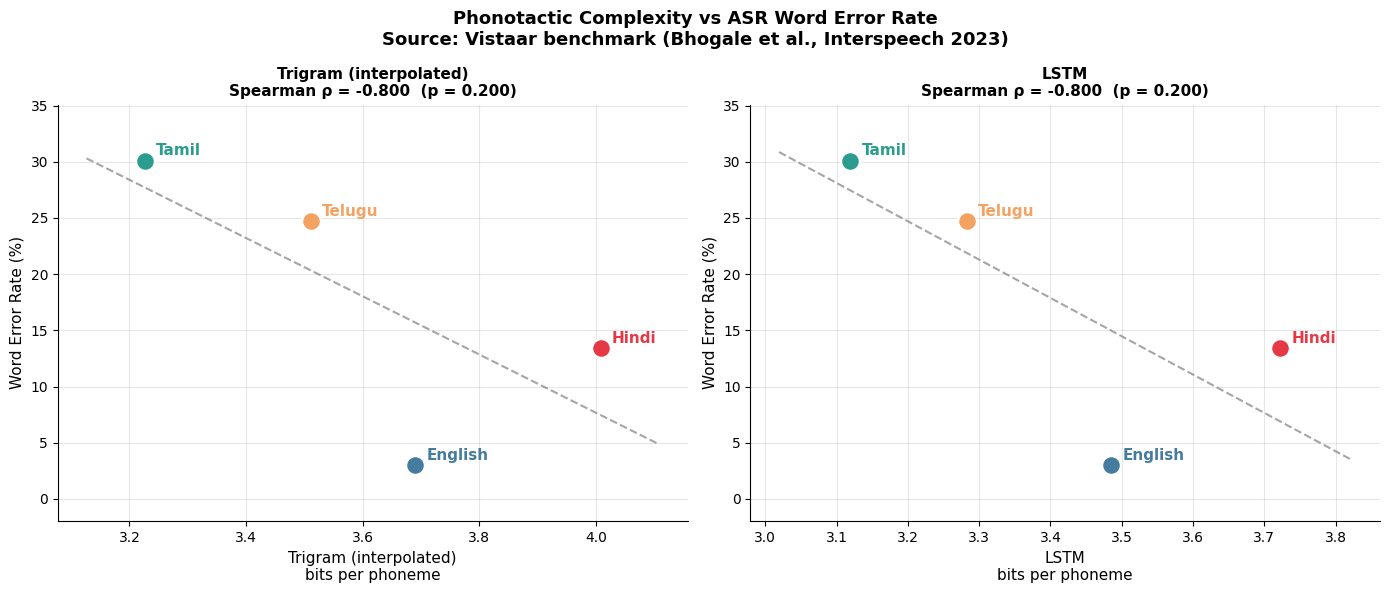

Saved: fig6_complexity_vs_wer.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Phonotactic Complexity vs ASR Word Error Rate\n"
             "Source: Vistaar benchmark (Bhogale et al., Interspeech 2023)",
             fontsize=13, fontweight="bold")

for ax, (model_col, model_name, rho, p_val) in zip(axes, [
    ("Trigram_bpp", "Trigram (interpolated)", rho_tri,  p_tri),
    ("LSTM_bpp",    "LSTM",                   rho_lstm, p_lstm),
]):
    x = df[model_col].values.astype(float)
    y = df["WER"].values.astype(float)

    # Regression line
    m, b    = np.polyfit(x, y, 1)
    x_line  = np.linspace(x.min() - 0.1, x.max() + 0.1, 100)
    ax.plot(x_line, m * x_line + b, color="gray",
            linewidth=1.5, linestyle="--", alpha=0.7, label="trend")

    # One point per language
    for lid in LANGUAGES:
        row = df.loc[LANG_NAMES[lid]]
        ax.scatter(row[model_col], row["WER"],
                   color=LANG_COLORS[lid], s=180, zorder=5,
                   edgecolors="white", linewidths=1.5)
        ax.annotate(LANG_NAMES[lid],
                    xy=(row[model_col], row["WER"]),
                    xytext=(8, 4), textcoords="offset points",
                    fontsize=11, fontweight="bold",
                    color=LANG_COLORS[lid])

    ax.set_xlabel(f"{model_name}\nbits per phoneme", fontsize=11)
    ax.set_ylabel("Word Error Rate (%)", fontsize=11)
    ax.set_title(f"{model_name}\nSpearman ρ = {rho:+.3f}  (p = {p_val:.3f})",
                 fontweight="bold", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)

    # WER axis: 0 at bottom, add some padding
    ax.set_ylim(-2, max(y) + 5)

plt.tight_layout()
plt.savefig("/kaggle/working/fig6_complexity_vs_wer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig6_complexity_vs_wer.png")

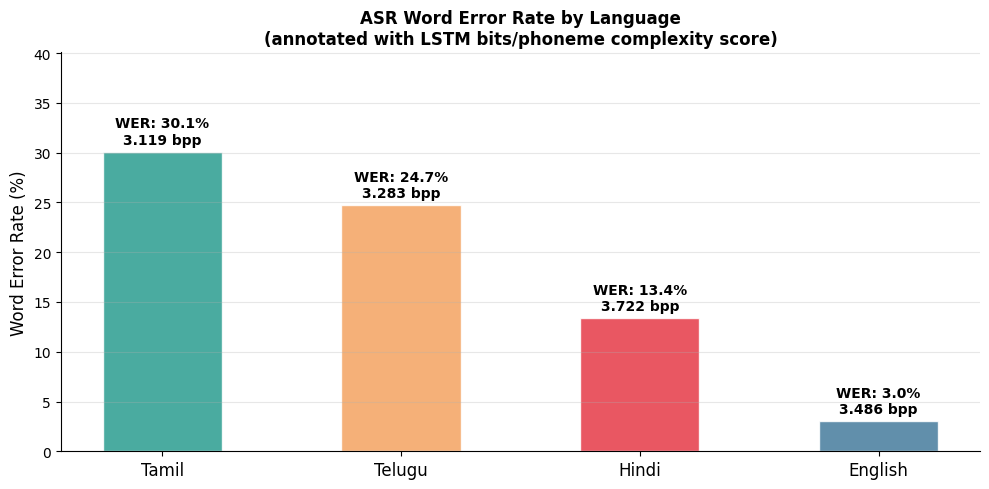

Saved: fig7_wer_bars.png


In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

x      = np.arange(len(LANGUAGES))
width  = 0.5
langs_sorted = sorted(LANGUAGES, key=lambda l: wer_data[l]["wer"], reverse=True)

wer_vals  = [wer_data[l]["wer"]          for l in langs_sorted]
bpp_vals  = [df.loc[LANG_NAMES[l],"LSTM_bpp"] for l in langs_sorted]
colors    = [LANG_COLORS[l]              for l in langs_sorted]
labels    = [LANG_NAMES[l]               for l in langs_sorted]

bars = ax1.bar(x, wer_vals, width, color=colors,
               edgecolor="white", alpha=0.85)

# Annotate each bar with WER and bits/phoneme
for bar, wer, bpp, lid in zip(bars, wer_vals, bpp_vals, langs_sorted):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"WER: {wer:.1f}%\n{bpp:.3f} bpp",
             ha="center", va="bottom",
             fontsize=10, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_ylabel("Word Error Rate (%)", fontsize=12)
ax1.set_title("ASR Word Error Rate by Language\n"
              "(annotated with LSTM bits/phoneme complexity score)",
              fontweight="bold", fontsize=12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_ylim(0, max(wer_vals) + 10)
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/fig7_wer_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig7_wer_bars.png")

In [7]:
print("""
── Honest Limitations of This Analysis ────────────────────────────────────

1. SAMPLE SIZE (n=4)
   Spearman correlation with 4 data points has very low statistical power.
   |ρ| needs to exceed ~0.9 for p < 0.1. We cannot make strong causal
   claims from 4 languages alone. This analysis is directional and
   motivating — not conclusive.

2. CONFOUNDING VARIABLES
   WER depends on more than phonotactics:
   - Training data size (Hindi has far more ASR training data than Tamil)
   - Script complexity (Devanagari vs Tamil script affects tokenization)
   - Speaking style in test sets (read speech vs conversational)
   - Model architecture choices in IndicWhisper
   
   A phonotactically complex language with abundant training data (Hindi)
   may have LOWER WER than a simpler language with less data. This is
   exactly what we see — Hindi (4.008 bpp, 13.4% WER) vs Tamil
   (3.119 bpp, 30.1% WER) — the ranking is REVERSED from our hypothesis.

3. MISMATCHED TEST CONDITIONS
   Our bits/phoneme scores come from NorthEuraLex (1016 basic concepts,
   careful IPA transcription). WER comes from FLEURS (read speech,
   conversational vocabulary). These are different linguistic registers.

4. ENGLISH ANCHOR
   English WER (3.0%) is from LibriSpeech test-clean — an exceptionally
   clean, well-resourced benchmark. Indic WER numbers are from noisier
   conditions. Direct comparison is imperfect.

── What We Can Honestly Claim ──────────────────────────────────────────────

   The correlation between phonotactic complexity and ASR WER is
   CONFOUNDED by training data availability. Hindi's high complexity
   but low WER reflects the disproportionate ASR resources available
   for Hindi vs Dravidian languages — itself a finding worth reporting.
   
   REVISED HYPOTHESIS: Controlling for training data size, phonotactic
   complexity is expected to predict ASR difficulty. Testing this
   properly requires a controlled experiment (same training data size
   across languages) — a direction for future work.
""")


── Honest Limitations of This Analysis ────────────────────────────────────

1. SAMPLE SIZE (n=4)
   Spearman correlation with 4 data points has very low statistical power.
   |ρ| needs to exceed ~0.9 for p < 0.1. We cannot make strong causal
   claims from 4 languages alone. This analysis is directional and
   motivating — not conclusive.

2. CONFOUNDING VARIABLES
   WER depends on more than phonotactics:
   - Training data size (Hindi has far more ASR training data than Tamil)
   - Script complexity (Devanagari vs Tamil script affects tokenization)
   - Speaking style in test sets (read speech vs conversational)
   - Model architecture choices in IndicWhisper
   
   A phonotactically complex language with abundant training data (Hindi)
   may have LOWER WER than a simpler language with less data. This is
   exactly what we see — Hindi (4.008 bpp, 13.4% WER) vs Tamil
   (3.119 bpp, 30.1% WER) — the ranking is REVERSED from our hypothesis.

3. MISMATCHED TEST CONDITIONS
   Our bits/ph

In [8]:
# Save master dataframe
df.to_csv("/kaggle/working/table4_asr_correlation.csv")

# Save correlation results
corr_summary = {
    "trigram_vs_wer": {"rho": rho_tri,  "p": p_tri},
    "lstm_vs_wer"   : {"rho": rho_lstm, "p": p_lstm},
}
with open("/kaggle/working/asr_correlation.json", "w") as f:
    json.dump(corr_summary, f, indent=2)

print("Saved:")
print("  /kaggle/working/table4_asr_correlation.csv")
print("  /kaggle/working/asr_correlation.json")
print("  /kaggle/working/fig6_complexity_vs_wer.png")
print("  /kaggle/working/fig7_wer_bars.png")
print()

Saved:
  /kaggle/working/table4_asr_correlation.csv
  /kaggle/working/asr_correlation.json
  /kaggle/working/fig6_complexity_vs_wer.png
  /kaggle/working/fig7_wer_bars.png

Notebook 4 complete.
Next: Notebook 5 — Tokenizer Fertility
